## Hemispherical asymmetry $\sigma_{16}$


In [1]:
import matplotlib.pyplot as plt
from scipy.stats import norm
import matplotlib.mlab as mlab
import numpy as np
import healpy as hp
import polymv
import pylab as pl
import math
import sys
sys.path.insert(1, '../../scripts')
import CMBanom
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

In [2]:
# Parameters
load_stats_from_cluster = True
gen_maps_on_fly = False
ecliptic_coords = True
Nside_out = 16
Nsims = 100000

In [3]:
# Directories
sims_dir  = "../../data/sims/sims_1k/"
stats_dir = "../../data/stats/"
real_dir  = "../../data/real/"
masks_dir = "../../data/masks/"

# Planck maps
names_Planck  = [  "commander_nside_128",   "nilc_nside_128",   "sevem_nside_128",   "smica_nside_128",     "cleaned_70GHz_v3",     "cleaned_94GHz_v3",     "cleaned_100GHz_v3",     "cleaned_143GHz_v3"]
labels_Planck = [r"$\mathrm{Commander}$", r"$\mathrm{NILC}$", r"$\mathrm{SEVEM}$", r"$\mathrm{SMICA}$", r"$70\, \mathrm{GHz}$", r"$94\, \mathrm{GHz}$", r"$100\, \mathrm{GHz}$", r"$143\, \mathrm{GHz}$"]
colors_Planck = ["tab:red", "teal",  "navy",  "gold", "tab:red",    "teal",   "navy",   "gold"]
lss_Planck    = [     "--",   "--",    "--",    "--",       "-",       "-",      "-",      "-"]
Nmaps = len(names_Planck)
index_Planck  = 0
index_Hayley  = 6

# Masks
names_mask  = [              "fullsky",                "stdmask",                  "commask"]
labels_mask = [r"$\mathrm{Full\ sky}$", r"$\mathrm{Std.\ mask}$", r"$\mathrm{Common\ mask}$"]
colors_mask = [                 "navy",              "firebrick",                 "tab:blue"]
mask_files = ["stdv_mask_1percent_cutoff0.9_Nside16.fits", "common-Mask-Int_cutoff0.9_Nside16.fits"]
mask_fn_south_ecl = "mask_south_ecl_Nside16.fits"
Nmasks = len(names_mask)

# Cls
cl_fn = "../../data/Cls/COM_PowerSpect_CMB-base-plikHM-TTTEEE-lowl-lowE-lensing-minimum-theory_R3.01.txt"

In [4]:
# Font
plt.rc('font',**{'family':'Helvetica','size':16})
plt.rc('text', usetex=True)
font = {'family':'Helvetica',
        'color' : 'black',
        'size'  :  16}
prop = {'family': 'Helvetica', 'size': 16}

In [5]:
masks_01 = CMBanom.read_masks(masks_dir, mask_files, Nside_out)

if ecliptic_coords:
    mask_for_north = hp.read_map(masks_dir+mask_fn_south_ecl)
    mask_for_south = np.where(hp.read_map(masks_dir+mask_fn_south_ecl)==1, 0, 1)
else:
    mask_for_north = np.append(np.ones(len_mask_16/2), np.zeros(len_mask_16/2))
    mask_for_north = np.append(np.zeros(len_mask_16/2), np.ones(len_mask_16/2))

masks = np.where(np.array([mask*mask_for_north for mask in masks_01])==0, np.NaN, 1)
masks_south = np.where(np.array([mask*mask_for_south for mask in masks_01])==0, np.NaN, 1)

In [6]:
# Read in maps in muK
maps_Planck_hr = [hp.read_map(real_dir+"map_"+names_Planck[n]+".fits") for n in range(Nmaps)]
maps_Planck_hr[4:] = [map * 1.e3 for map in maps_Planck_hr[4:]]
maps_Planck = np.array([CMBanom.downgrade_map(maps_Planck_hr[n], Nside_out) for n in range(Nmaps)])

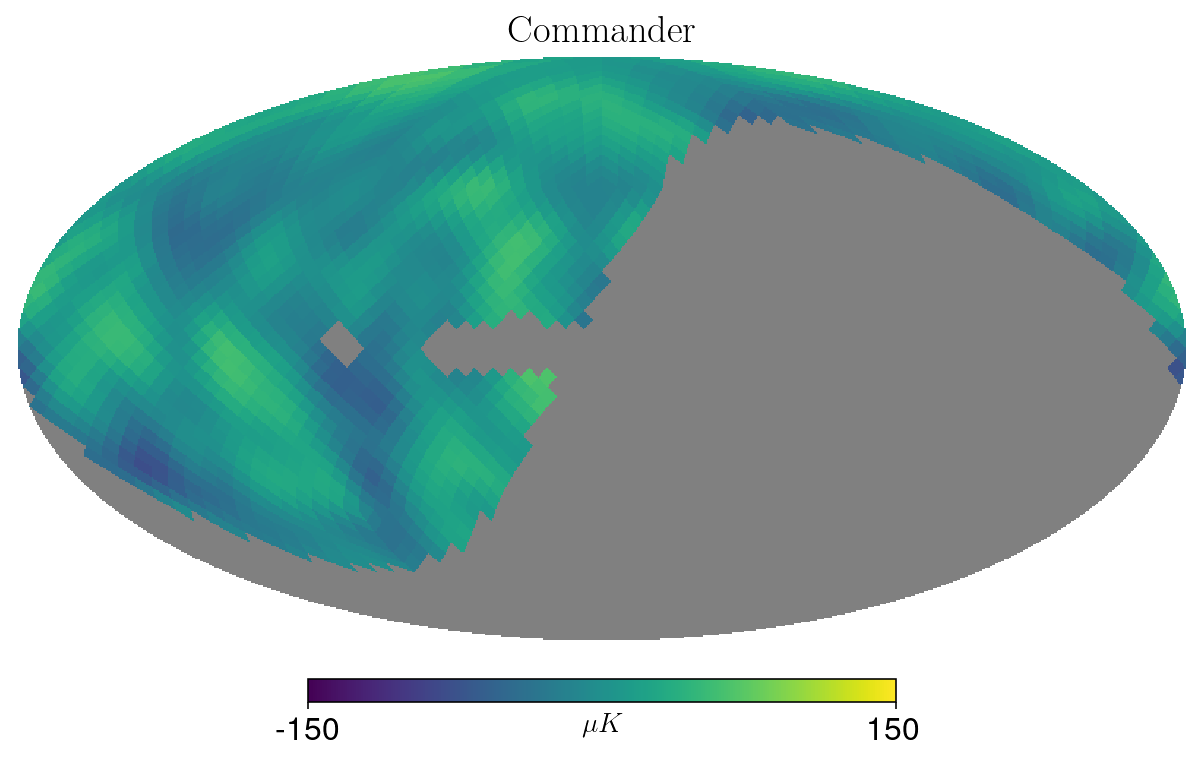

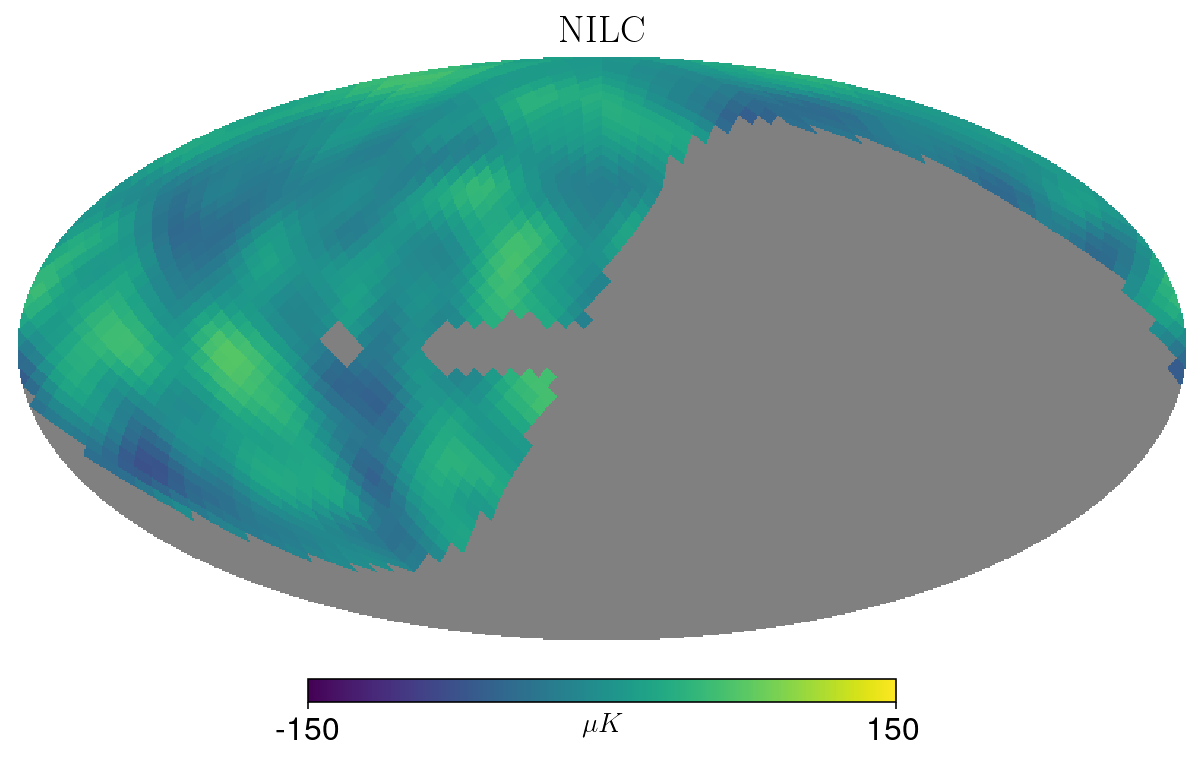

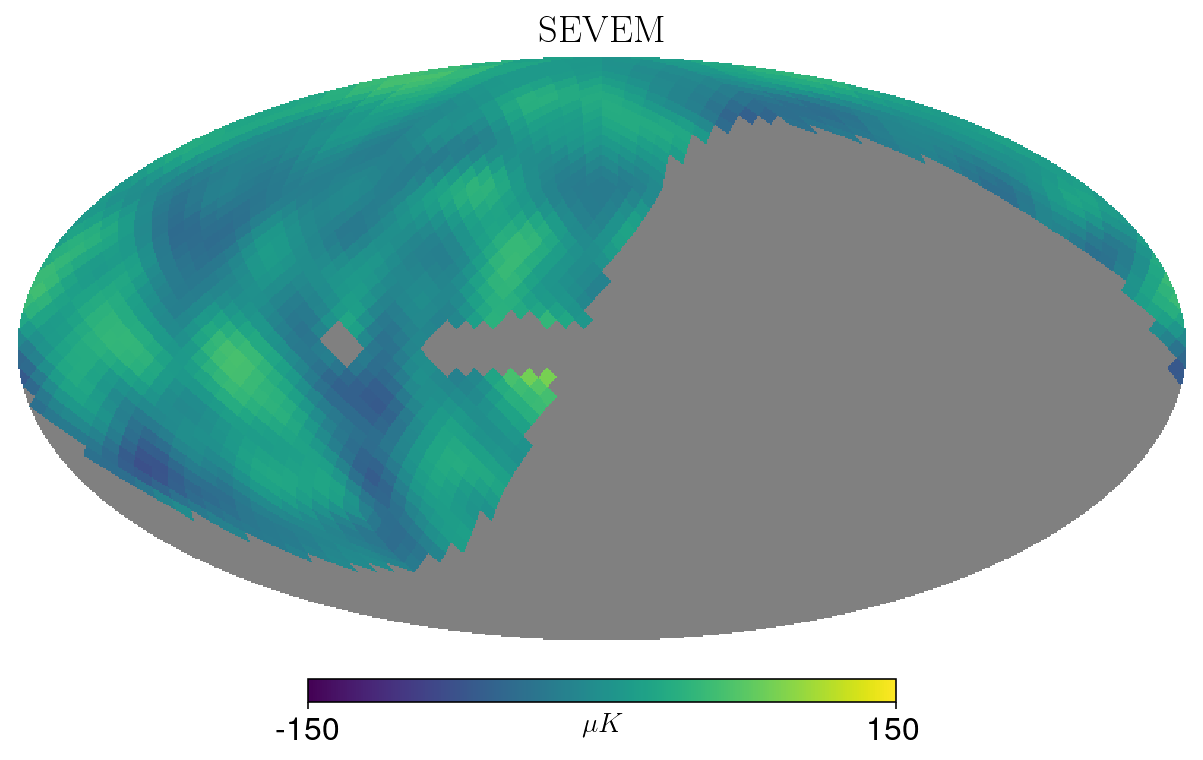

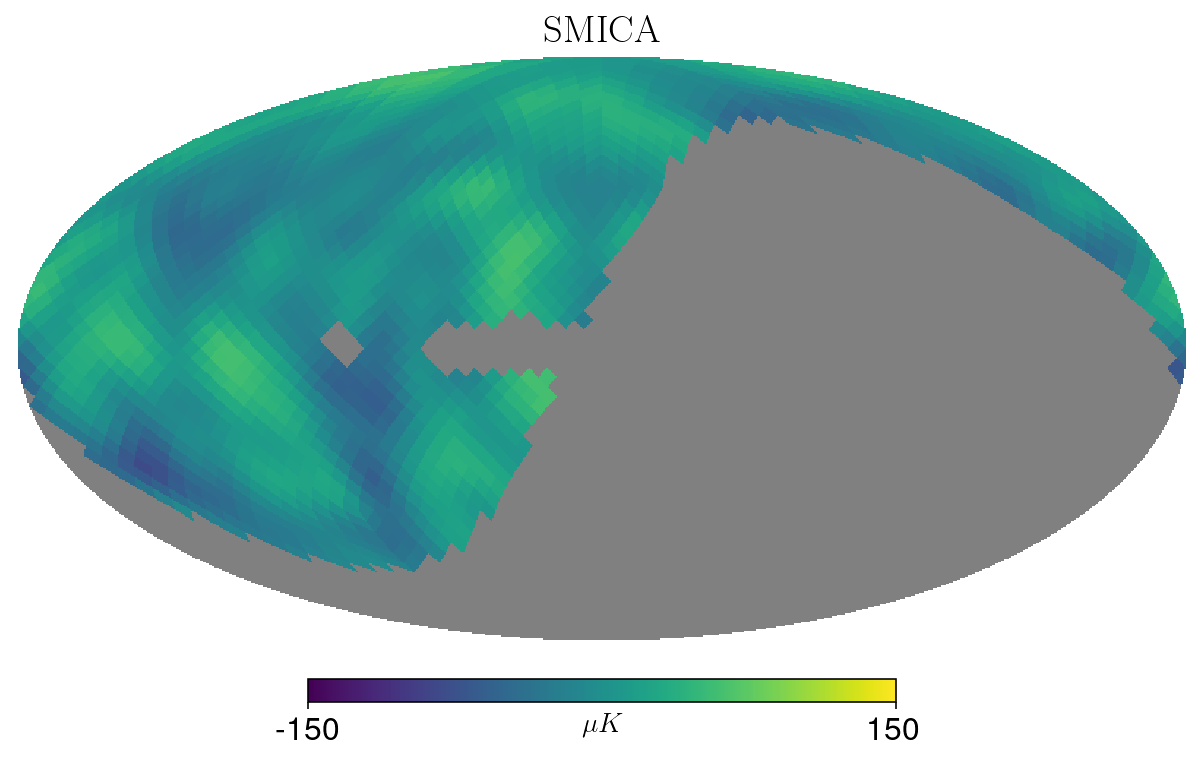

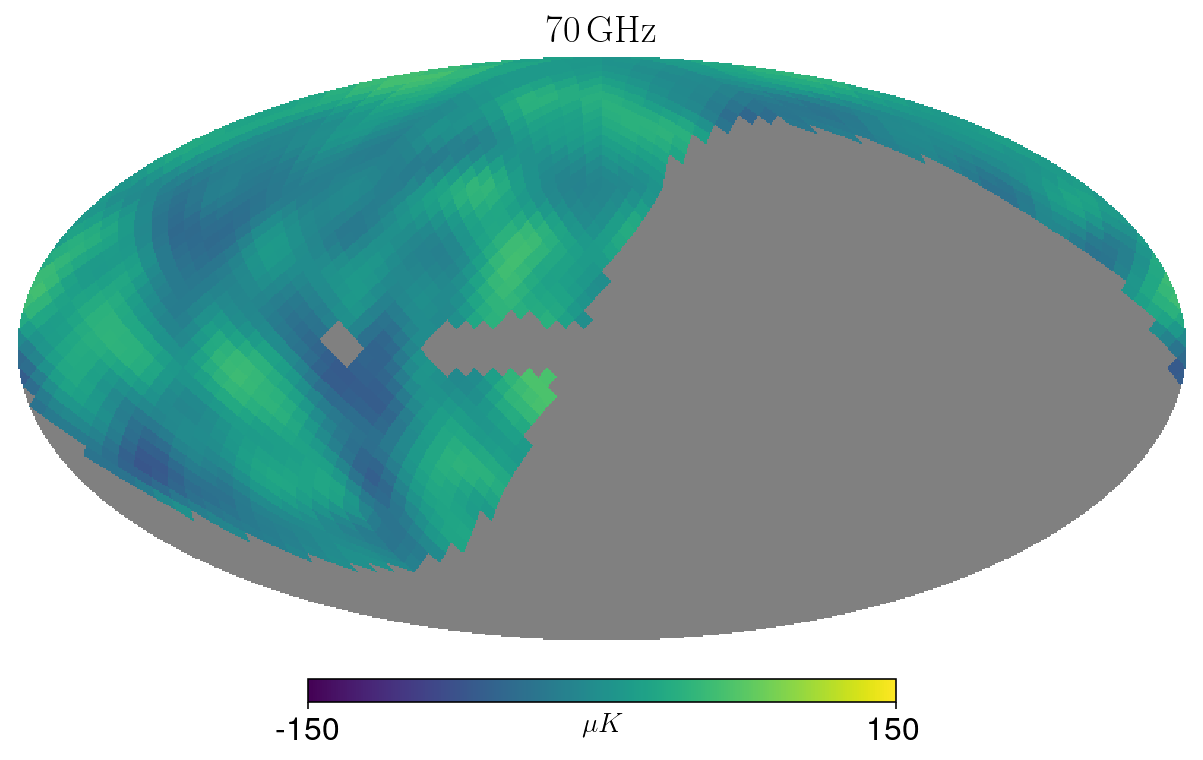

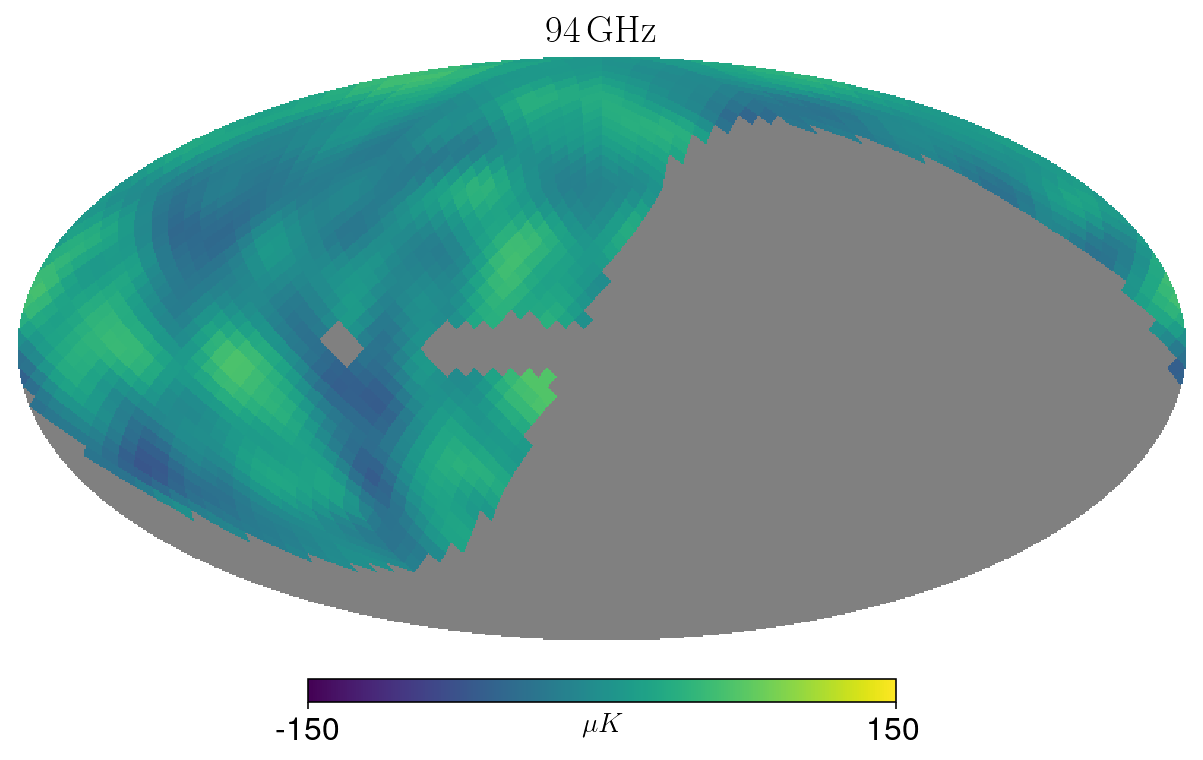

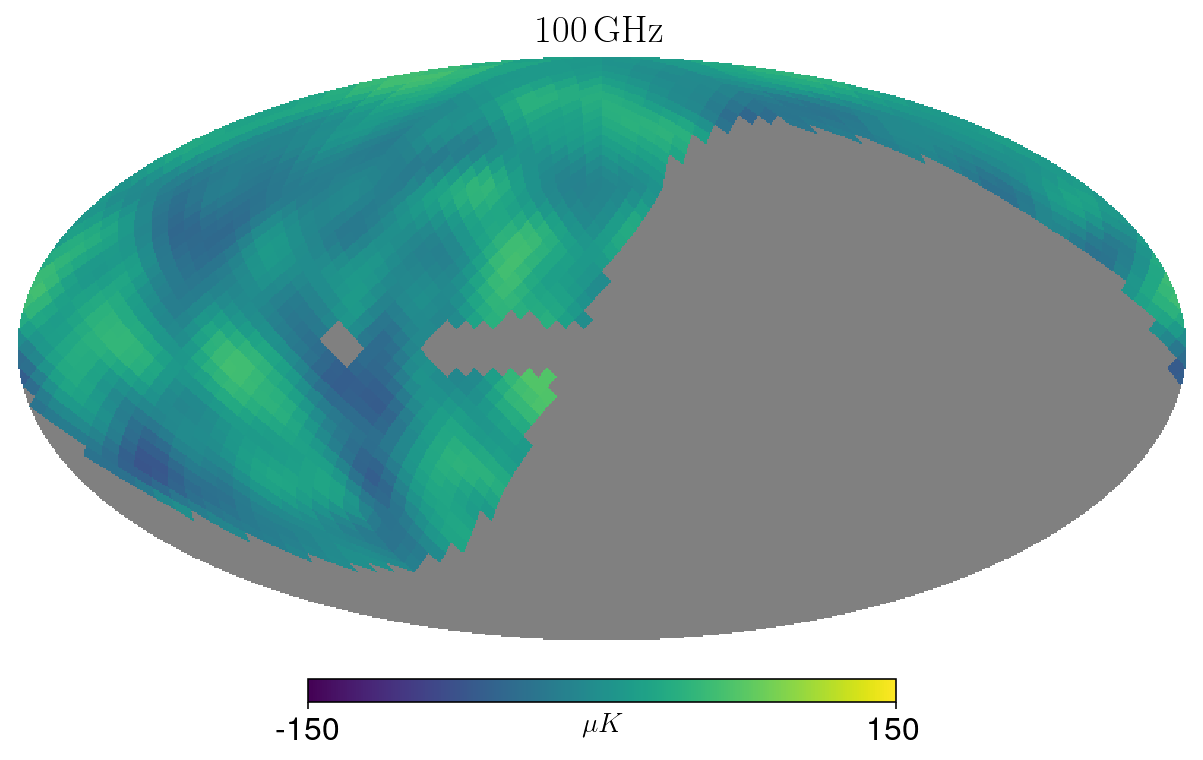

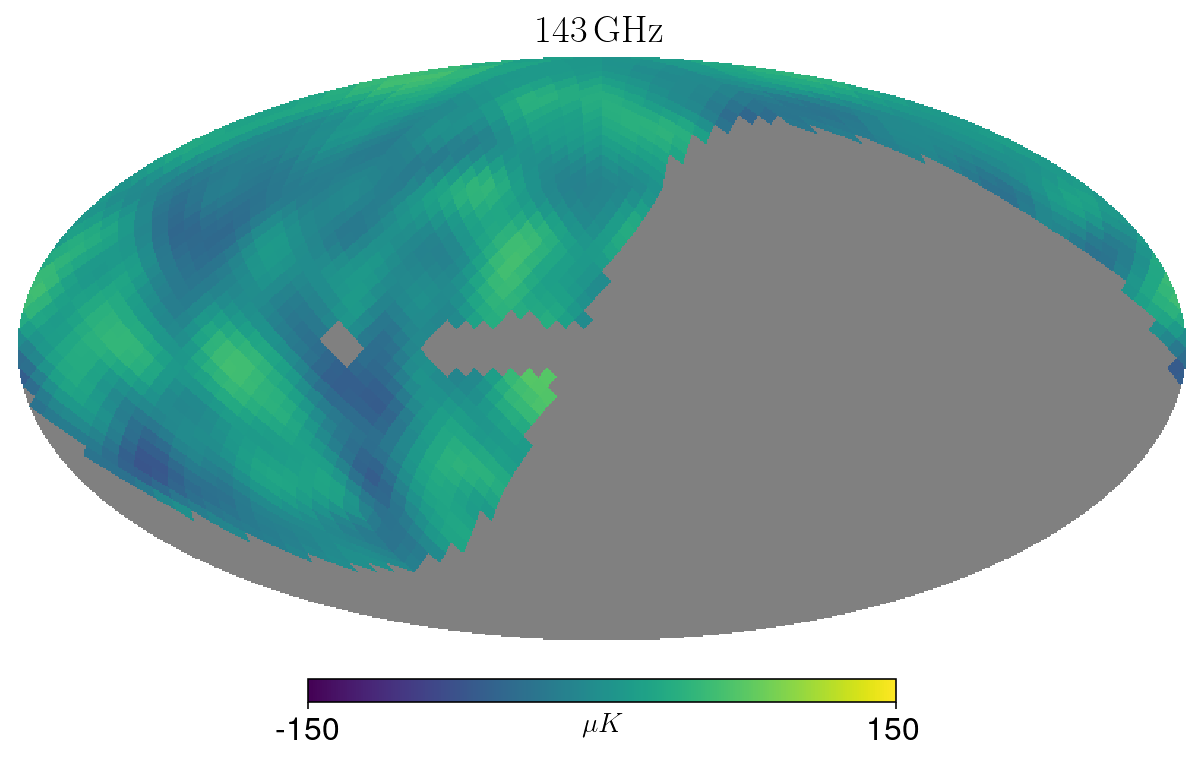

In [19]:
# Plot map
for n in range(Nmaps): hp.mollview(maps_Planck[n]*masks[1], min=-150, max=150, unit=r"$\mu K$", title=labels_Planck[n])

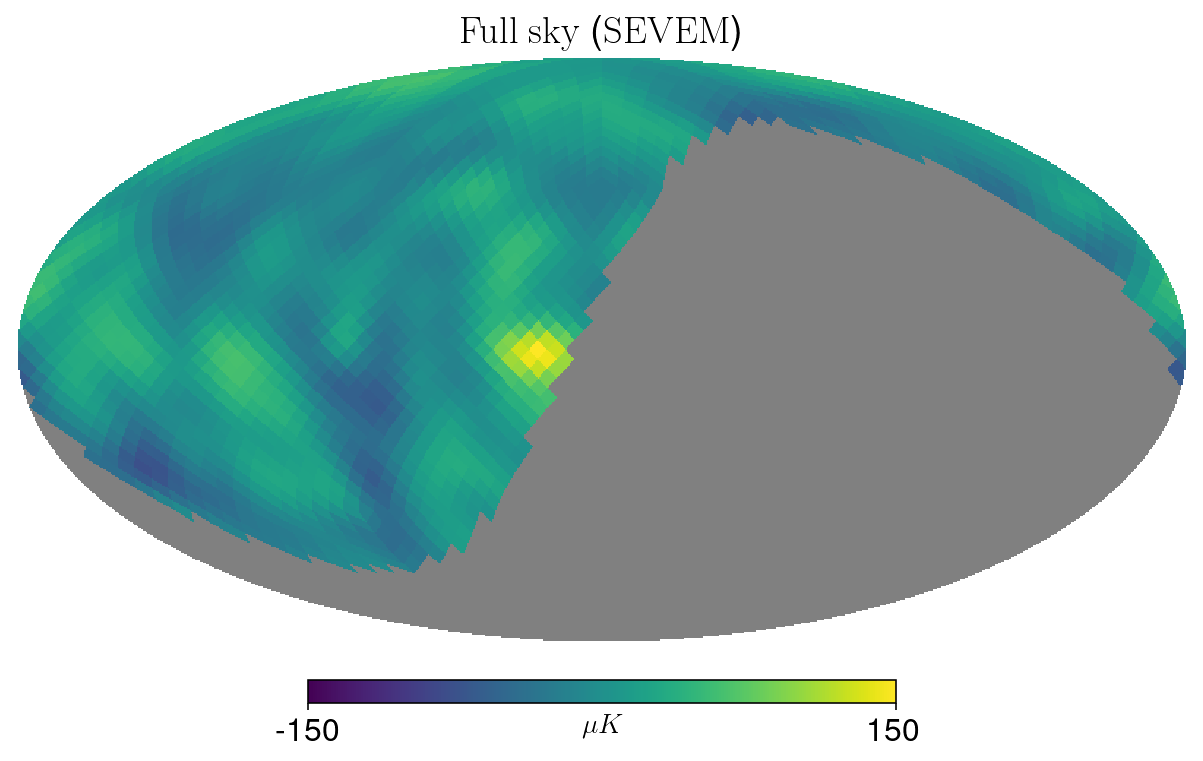

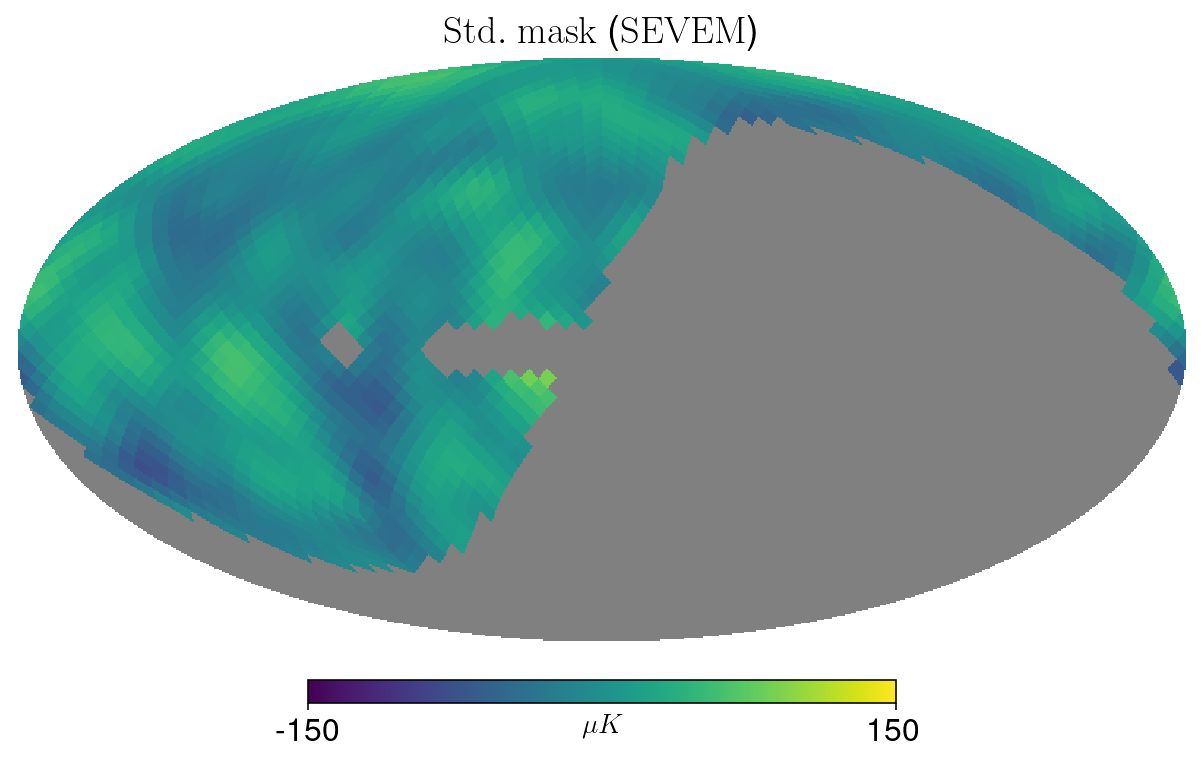

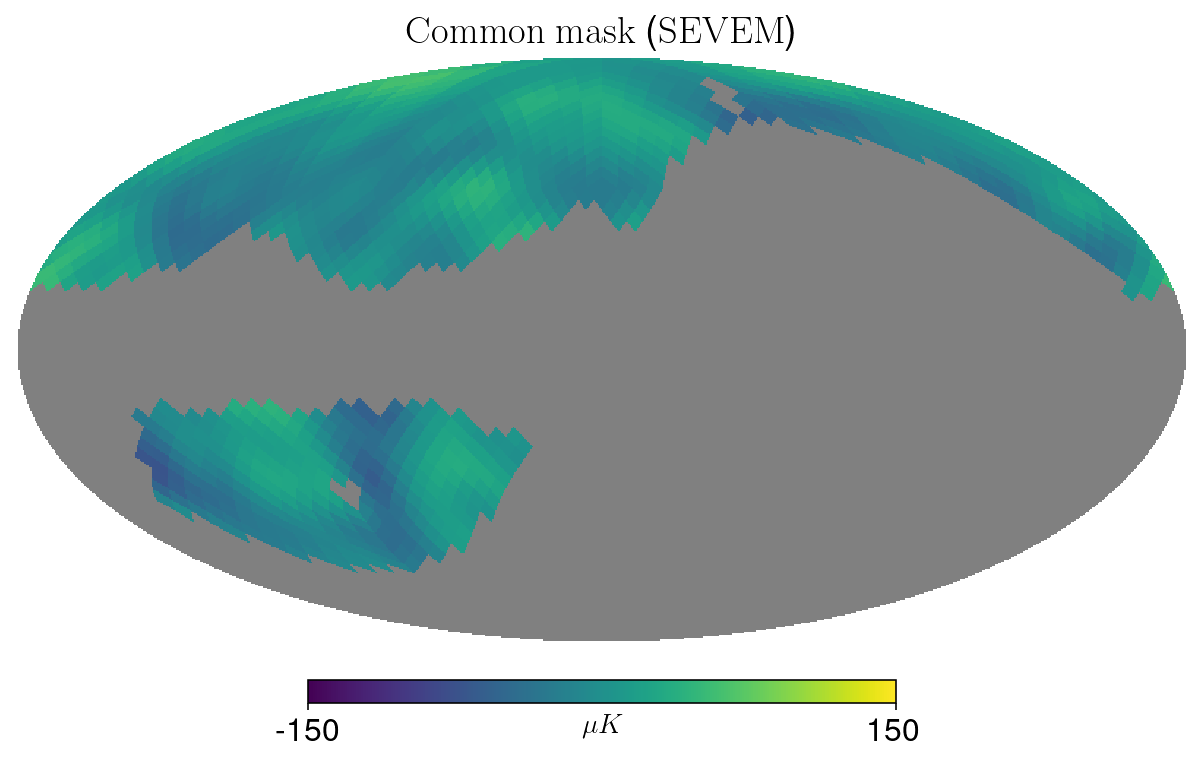

In [8]:
# Plot map
n = 2
for m in range(Nmasks): hp.mollview(maps_Planck[n]*masks[m], min=-150, max=150, unit=r"$\mu K$", title=f"{labels_mask[m]} ({labels_Planck[n]})")

## Compute variance

In [9]:
vars_Planck = np.array([[CMBanom.sigma_16(maps_Planck[n],masks[m]) for n in range(Nmaps)] for m in range(Nmasks)])

## Sims
Generate maps, compute variance on northern hemisphere on the fly without saving the map

In [10]:
if load_stats_from_cluster:
    vars_sims = [np.loadtxt(stats_dir+f"sigma16_sims_{names_mask[m]}_Nsims_{Nsims}.npy") for m in range(Nmasks)]
else:
    if gen_maps_on_fly:
        NSIDEtoFWHMarcmin = {2048:5, 1024:10, 512:20, 256:40, 128:80, 64:160, 32:320, 16:640}
        lmax=200
        data = np.loadtxt(cl_fn, skiprows=1)
        llist = np.arange(lmax+1)
        Clist = np.zeros(lmax+1)
        Clist[2:] = data[:lmax-1, 1]*2.*np.pi/(llist[2:]*(llist[2:] + 1))

        # Generate maps and save var
        vars_sims = [[],[],[]]
        seeds = np.arange(0,Nsims)
        for seed in seeds:
            np.random.seed(seed)
            m_128 = hp.sphtfunc.synfast(Clist, nside=128, fwhm=CMBanom.arcmin2rad(NSIDEtoFWHMarcmin[128]), pixwin=True)  
            m = CMBanom.downgrade_map(m_128, Nside_out)
            vars_sims[0].append(CMBanom.sigma_16(m, mask_for_north))
            vars_sims[1].append(CMBanom.sigma_16(m, mask_for_north*mask_std))
            vars_sims[2].append(CMBanom.sigma_16(m, mask_for_north*mask_com))
        
    else:
        maps_128  = [hp.read_map(sims_dir+f"map__{n}.fits") for n in range(Nsims)]
        maps_16   = [CMBanom.downgrade_map(map, Nside_out) for map in maps_128]
        vars_sims = [[CMBanom.sigma_16(map, mask) for map in maps_16] for mask in masks]
    hp.mollview(maps_16[12]*masks[1], title="sim", unit=r"$\mu K$", min=-150, max=150)
mean_vars_sims = np.mean(np.array(vars_sims),axis=1)

## Compare northern & southern hemisphere

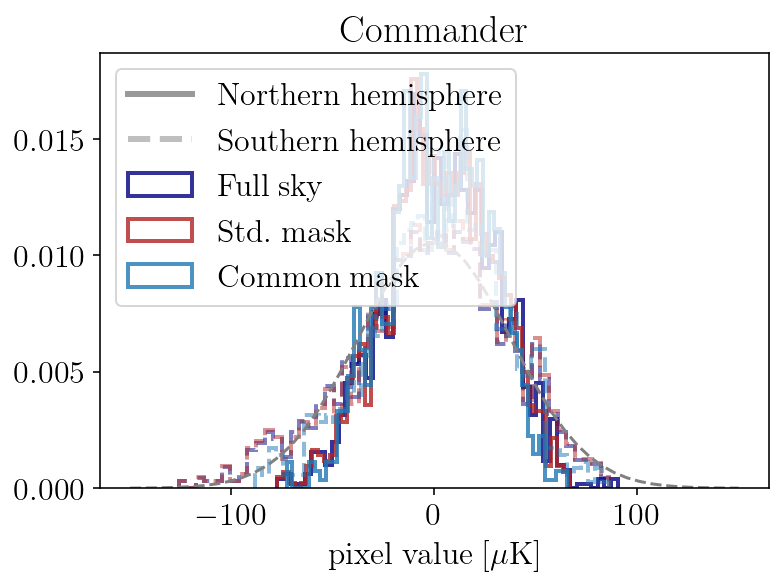

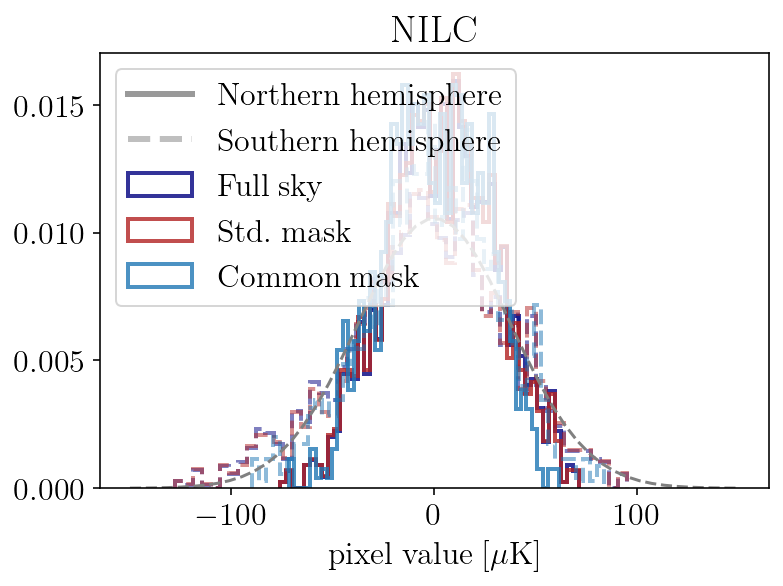

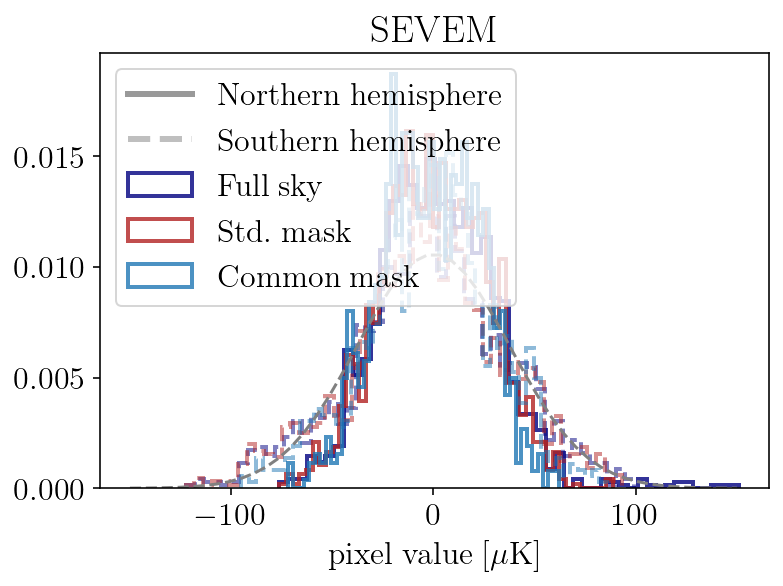

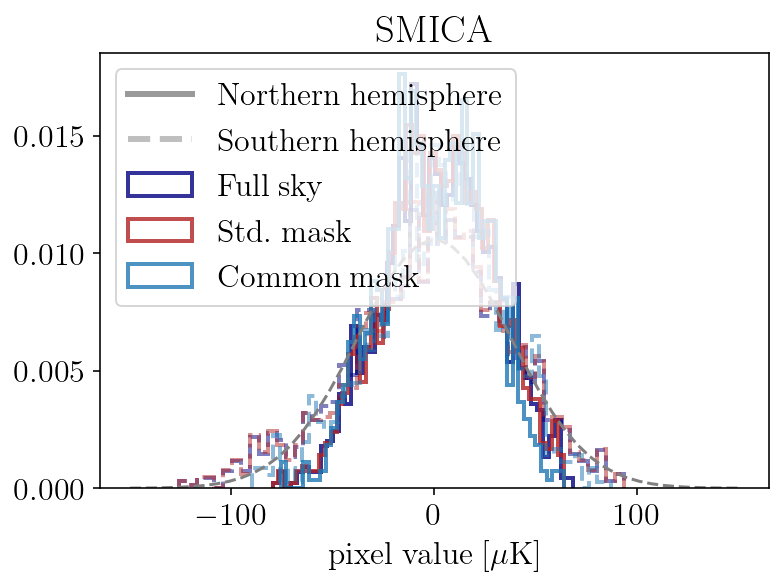

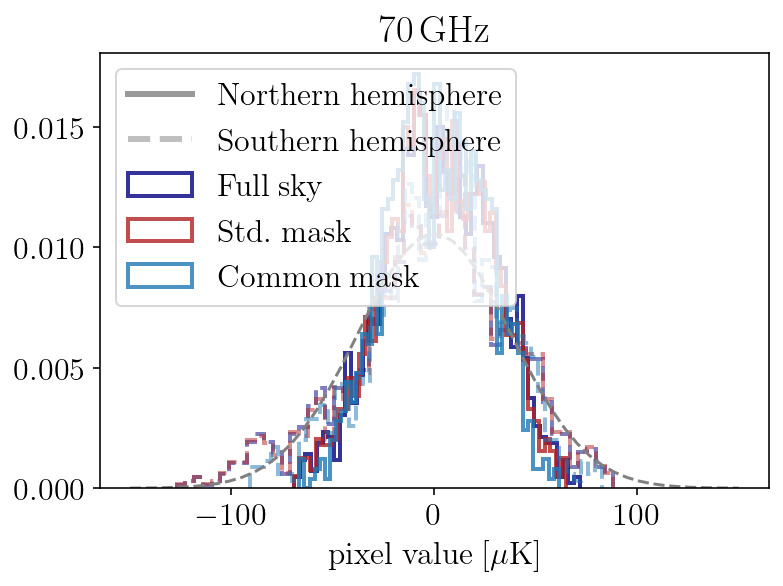

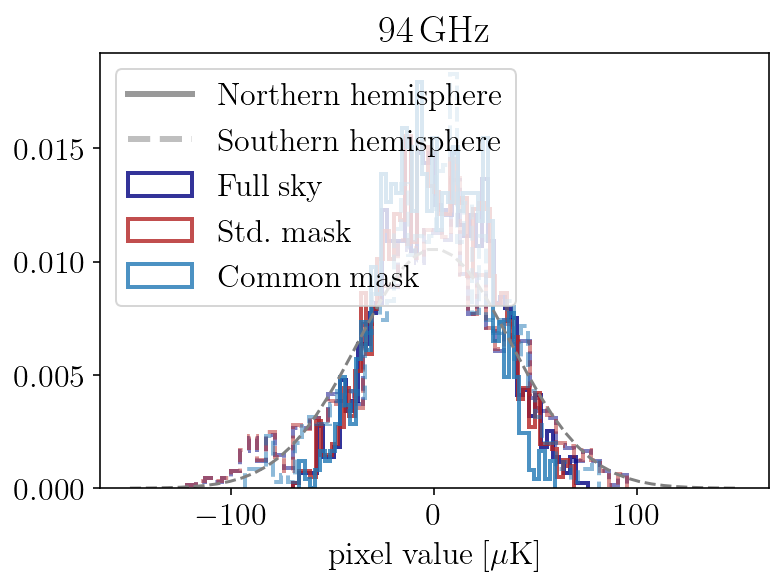

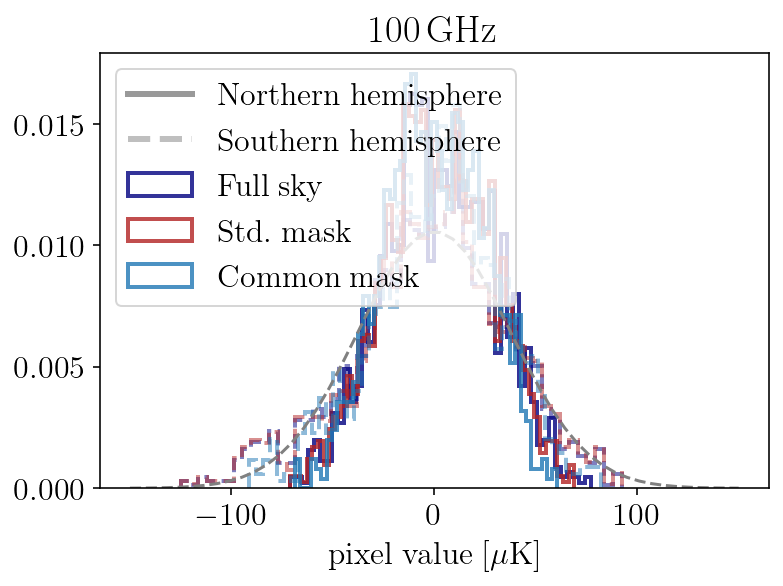

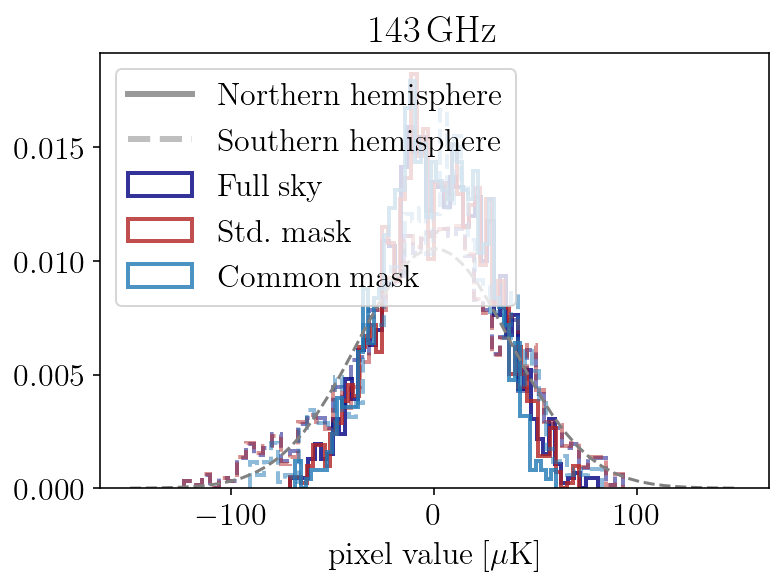

In [11]:
for n in range(Nmaps):
    plt.plot([0], [0], color='grey', alpha=0.8, ls="-",  lw=3, label=r'$\mathrm{Northern\ hemisphere}$')
    plt.plot([0], [0], color='grey', alpha=0.5, ls="--", lw=3, label=r'$\mathrm{Southern\ hemisphere}$')
    for m in range(Nmasks):
        h=plt.hist(maps_Planck[n]*masks[m], bins=50, alpha=0.8, label=labels_mask[m], histtype="step", lw=2, color=colors_mask[m], density=True)
        h=plt.hist(maps_Planck[n]*masks_south[m], bins=50, alpha=0.5, histtype="step", lw=2, color=colors_mask[m], density=True, ls="--")
    plt.plot(np.linspace(-150,150, 50), norm.pdf(np.linspace(-150,150, 50), 0, np.sqrt(mean_vars_sims[0])), color="grey", ls="--")

    plt.title(labels_Planck[n])
    plt.xlabel(r"$\mathrm{pixel\ value\ [}\mu \mathrm{K]}$")
    plt.legend(loc="upper left", prop=prop)
    plt.show()

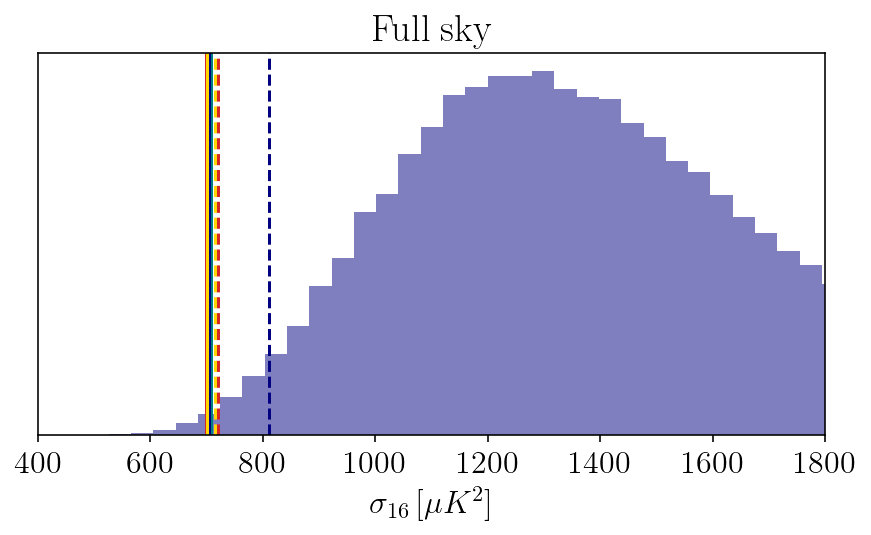

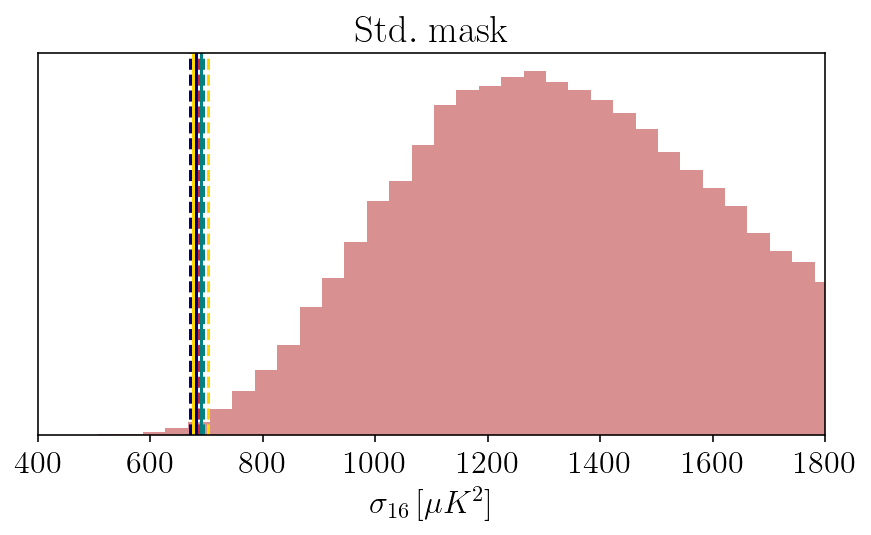

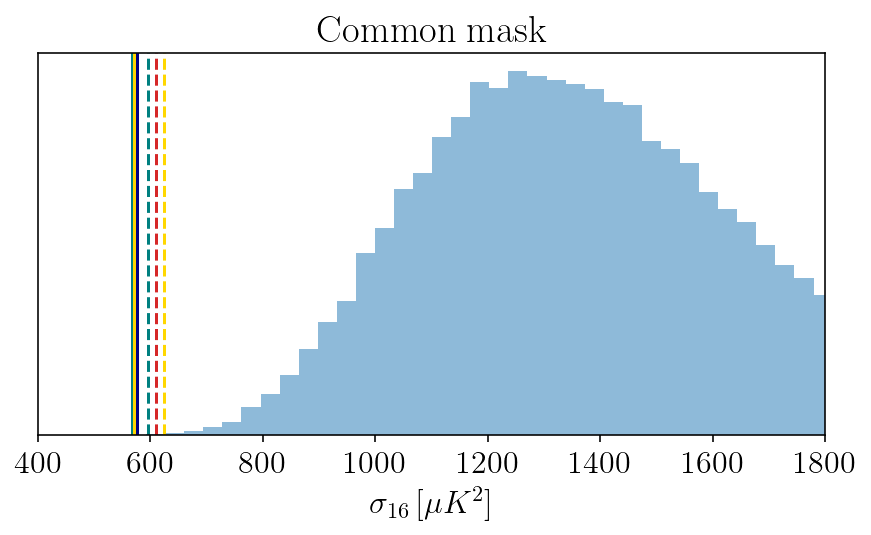

In [12]:
for m in range(Nmasks):
    plt.title(labels_mask[m])
    h=plt.hist(vars_sims[m], bins=100, alpha=0.5, color=colors_mask[m])
    for n in range(Nmaps): plt.axvline(vars_Planck[m][n], label=labels_Planck[n], color=colors_Planck[n], ls=lss_Planck[n])
    plt.xlim(400, 1800)
    plt.xlabel(r"$\sigma_{16}\, [\mu K^2]$")
    #plt.legend(loc="lower right")
    plt.tick_params(axis='y', which='both', left=False, labelleft=False) 
    plt.tight_layout()
    plt.savefig("hist_sigma16_"+names_mask[m]+".pdf", format="PDF")
    plt.show()


## Make summary plot

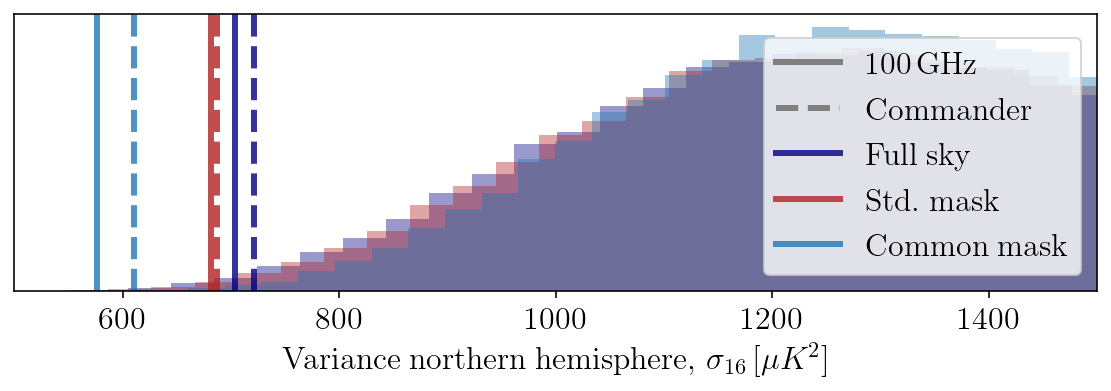

In [13]:
fig = plt.figure(figsize=(8, 3))
plt.plot([0], [0], color='grey', ls="-", lw=3, label=labels_Planck[index_Hayley])
plt.plot([0], [0], color='grey', ls="--", lw=3, label=labels_Planck[index_Planck])
for m in range(Nmasks):
    h=plt.hist(vars_sims[m], bins=100, alpha=0.4, density=True, color=colors_mask[m])
    plt.axvline(vars_Planck[m][index_Hayley], color=colors_mask[m], alpha=0.8, lw=3, ls="-", label=labels_mask[m])
    plt.axvline(vars_Planck[m][index_Planck], color=colors_mask[m], alpha=0.8, lw=3, ls="--")
plt.xlim(500, 1500)
plt.xlabel(r"$\mathrm{Variance\ northern\ hemisphere,}\ \sigma_{16}\, [\mu K^2]$")
plt.tick_params(axis='y', which='both', left=False, labelleft=False) 
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("hist_sigma16.pdf", format="PDF")
plt.show()

## Compute p-values

In [14]:
pvals = [[CMBanom.pval_lower(vars_Planck[m][n], vars_sims[m]) for n in range(Nmaps)] for m in range(Nmasks)]

In [15]:
for m in range(Nmasks):
    print("-----------")
    print(names_mask[m])
    for n in range(Nmaps):
        print(f"sigma_16 = {vars_Planck[m][n]:.2f}, p-value: {100*pvals[m][n]:.3f}% ({names_Planck[n]})")
    #print(f"sigma_16 = {vars_Planck_std_mask[n]:.2f}, p-value: {100*pvals_std_mask[n]:.2f}% ({labels_Planck[n]})")

-----------
fullsky
sigma_16 = 720.99, p-value: 0.501% (commander_nside_128)
sigma_16 = 700.67, p-value: 0.339% (nilc_nside_128)
sigma_16 = 811.54, p-value: 1.952% (sevem_nside_128)
sigma_16 = 714.90, p-value: 0.448% (smica_nside_128)
sigma_16 = 698.41, p-value: 0.327% (cleaned_70GHz_v3)
sigma_16 = 707.75, p-value: 0.394% (cleaned_94GHz_v3)
sigma_16 = 704.16, p-value: 0.358% (cleaned_100GHz_v3)
sigma_16 = 700.43, p-value: 0.338% (cleaned_143GHz_v3)
-----------
stdmask
sigma_16 = 686.69, p-value: 0.222% (commander_nside_128)
sigma_16 = 694.28, p-value: 0.253% (nilc_nside_128)
sigma_16 = 669.80, p-value: 0.163% (sevem_nside_128)
sigma_16 = 702.84, p-value: 0.311% (smica_nside_128)
sigma_16 = 675.69, p-value: 0.180% (cleaned_70GHz_v3)
sigma_16 = 689.34, p-value: 0.233% (cleaned_94GHz_v3)
sigma_16 = 681.44, p-value: 0.200% (cleaned_100GHz_v3)
sigma_16 = 675.45, p-value: 0.179% (cleaned_143GHz_v3)
-----------
commask
sigma_16 = 610.40, p-value: 0.008% (commander_nside_128)
sigma_16 = 596.12

### Compare to Jones++ 2023 (common mask)
$\sigma_{16} = 617.6,\ \text{p-value:}\ 0.31\%$ (Commander)

$\sigma_{16} = 605.9,\ \text{p-value:}\ 0.25\%$ (NILC)

$\sigma_{16} = 583.4,\ \text{p-value:}\ 0.16\%$ (SEVEM)

$\sigma_{16} = 631.0,\ \text{p-value:}\ 0.39\%$ (SMICA)

In [16]:
print("p-values")
for m in range(Nmasks):
    print(names_mask[m],": ", end="")
    for n in range(Nmaps):
        print(f"&{100*pvals[m][n]:.3f} ", end="")
    print("\\\\")

p-values
fullsky : &0.501 &0.339 &1.952 &0.448 &0.327 &0.394 &0.358 &0.338 \\
stdmask : &0.222 &0.253 &0.163 &0.311 &0.180 &0.233 &0.200 &0.179 \\
commask : &0.008 &0.005 &0.002 &0.013 &0.001 &0.001 &0.002 &0.002 \\


In [17]:
print("stats")
for m in range(Nmasks):
    print(names_mask[m],": ", end="")
    for n in range(Nmaps):
        print(f"&{vars_Planck[m][n]:.0f} ", end="")
    print("\\\\")

stats
fullsky : &721 &701 &812 &715 &698 &708 &704 &700 \\
stdmask : &687 &694 &670 &703 &676 &689 &681 &675 \\
commask : &610 &596 &576 &623 &568 &568 &576 &571 \\
